### Imports and plotting setting

In [15]:
import numpy as np
from scipy.optimize import fsolve, root

# import predefined functions wich solve the box model
import fct_BoxModel as fbm

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)
lipari = cmcra.lipari

### Importing the input dataset

In [2]:
# inputs from BoxToReal.ipynb
inputs = xr.open_dataset("../model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

def arrond(x):
    return np.round(x,-int(np.floor(np.log10(abs(x)))))

arrond(-0.000158)

np.float64(-0.0002)

### Defining the parameters

In [3]:
#PICO parameters
# Reese 2018
C = 1e6 #m^6/s/kg
gammaT = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

#AABW
C2 = 4e6 #m^6/s/kg

# densities
rho_i = 910 #kg/m^3
rho_w = 1033 #kg/m^3

### Plot Figure 3 y-axis $A_p$

Ross
Filchner-Ronne
Amery
Dotson
Pine Island
Riiser-Larsen
Roi Baudouin
no conv, diff 0 1
no conv, diff 1 1
no conv, diff 0 2


/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/Figure3_try/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


Totten
Moscow Univ.


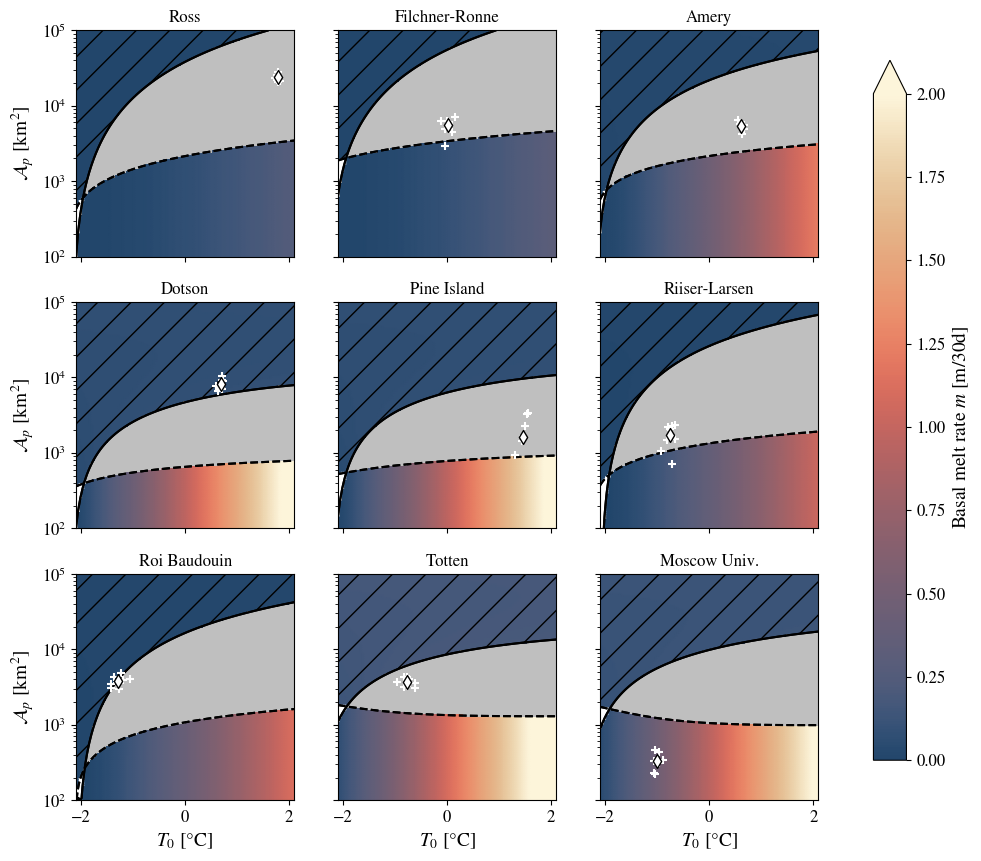

In [15]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(0) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True, sharey=True)

Npoint = 100 #Number of points in the figures (total is Npoint**2)

#WDW temperature
T0_list = np.linspace(-2.1,2.1,Npoint) # For the x-axis

#Ap
Ap_list = np.logspace(8,11,Npoint) 

for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here
    #Ap_list = np.logspace(np.log10(Ap_ref/20),np.log10(Ap_ref*10),Npoint) # For the y-axis #submitted version
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    ax[i,j].pcolormesh(T0_list,Ap_list/1e6,melt_c,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    melt_diff = ax[i,j].pcolormesh(T0_list,Ap_list/1e6,melt_d,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(T0_list,Ap_list/1e6,bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    ax[i,j].contour(T0_list,Ap_list/1e6,sigma_d,colors='black',levels=0)
    ax[i,j].contour(T0_list,Ap_list/1e6,sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(T0_list,Ap_list/1e6,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(T0_list,Ap_list/1e6,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),hatches='/',levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(T0_list,Ap_list/1e6,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((-2.1,2.1))
    
    #ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6)) # Submitted Version
    ax[i,j].set_ylim((1e2,1e5)) # same y-axis, Ap
    
    if j==0:
        ax[i,j].set_ylabel(r'$\mathcal{A}_p$'+' '+r'$\mathrm{[km^2]}$')
    if i==2:
        ax[i,j].set_xlabel(r'$T_0$'+' [°C]')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values*2/3 #2/3 factors because only March to October rates here
    
    ax[i,j].scatter(T0_series,Ap_series/1e6,marker='+', c='white', zorder=2) # Ap in km²

    ax[i,j].scatter(np.mean(T0_series),np.mean(Ap_series)/1e6,facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/30d]', extend='max')
#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

### y: $A_p \Omega$

In [231]:
def arrond(x):
    return np.round(x,-int(np.floor(np.log10(abs(x)))))

arrond(-0.000158)

np.float64(-0.0002)

Ross
Filchner-Ronne
Amery
Dotson
Pine Island
Riiser-Larsen
Roi Baudouin
no conv, diff 0 1


/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/Figure3_try/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


Totten
Moscow Univ.


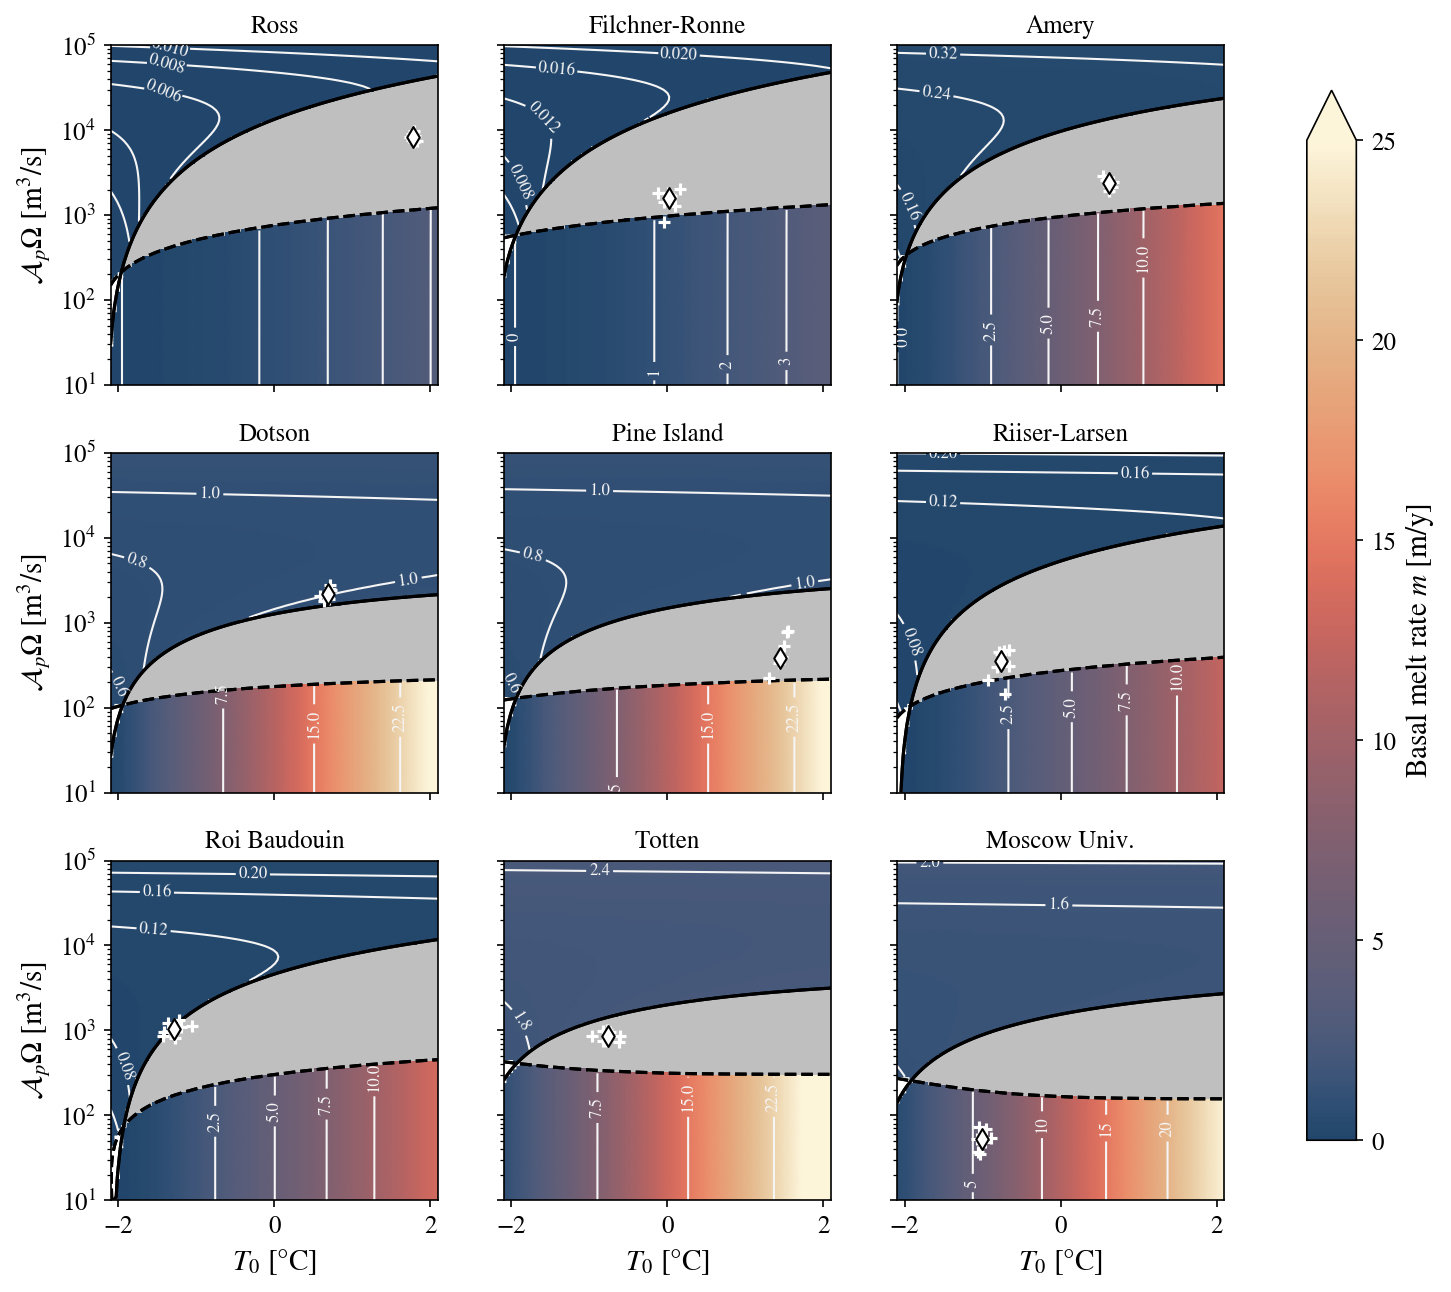

In [232]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(28) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True, sharey=True, dpi=150)

Npoint = 100 #Number of points in the figures (total is Npoint**2)

#WDW temperature
T0_list = np.linspace(-2.1,2.1,Npoint) # For the x-axis

for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(1,5,Npoint)
    Ap_list = y_axis/Omega_ref
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    melt_c = melt_c*12 # m/y
    ax[i,j].pcolormesh(T0_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=25,shading='gouraud') # Ap in km²

    contour_c = np.ma.masked_where(stability_map !=-1,melt_c)
    bound = arrond(np.nanmax(contour_c))
    cont = ax[i,j].contour(T0_list, y_axis, contour_c, np.linspace(bound/5,bound,5), colors='whitesmoke', linewidths=1) 
    ax[i,j].clabel(cont, fontsize=8)

    melt_d = melt_d*12 # m/y
    melt_diff = ax[i,j].pcolormesh(T0_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=25,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(T0_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    contour_d = np.ma.masked_where(stability_map !=1,melt_d)
    bound = arrond(np.nanmax(contour_d))
    cont = ax[i,j].contour(T0_list, y_axis, contour_d, np.linspace(0,bound,5), colors='whitesmoke', linewidths=1)
    ax[i,j].clabel(cont, fontsize=8,)

    ax[i,j].contour(T0_list, y_axis, sigma_d,colors='black',levels=0)
    ax[i,j].contour(T0_list, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(T0_list,y_axis,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(T0_list,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),
                         levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(T0_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((-2.1,2.1))
    
    #ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6)) # Submitted Version
    ax[i,j].set_ylim((1e1,1e5)) # same y-axis, Ap Omega
    
    if j==0:
        ax[i,j].set_ylabel(r'$\mathcal{A}_p \Omega$'+' '+r'$\mathrm{[m^3/s]}$')
    if i==2:
        ax[i,j].set_xlabel(r'$T_0$'+' [°C]')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values*2/3 #2/3 factors because only March to October rates here
    
    ax[i,j].scatter(T0_series,Ap_series*Omega_ref,marker='+', c='white', zorder=2) 
    ax[i,j].scatter(np.mean(T0_series),np.mean(Ap_series)*Omega_ref,facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/y]', extend='max')
#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

### $\Phi f_S$

Ross
Filchner-Ronne
Amery
Dotson
Pine Island
Riiser-Larsen
Roi Baudouin
no conv, diff 0 1
no conv, diff 1 1
no conv, diff 0 2


/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/Figure3_try/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


Totten
Moscow Univ.


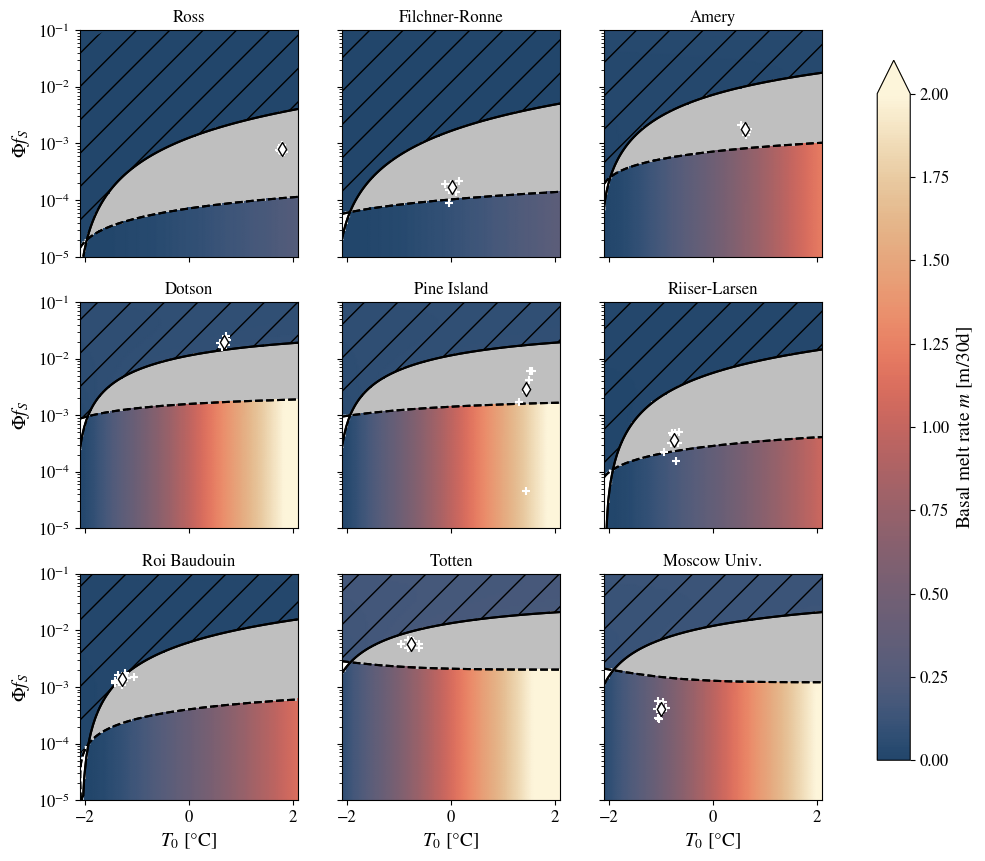

In [40]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(0) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True, sharey=True)

Npoint = 100 #Number of points in the figures (total is Npoint**2)

#WDW temperature
T0_list = np.linspace(-2.1,2.1,Npoint) # For the x-axis

for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(-5,-1,Npoint)
    Ap_list = y_axis*rho_w/rho_i/Omega_ref*Ac*gammaT
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    ax[i,j].pcolormesh(T0_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    melt_diff = ax[i,j].pcolormesh(T0_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(T0_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    ax[i,j].contour(T0_list, y_axis, sigma_d,colors='black',levels=0)
    ax[i,j].contour(T0_list, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(T0_list,y_axis,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(T0_list,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),hatches='/',levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(T0_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((-2.1,2.1))
    
    #ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6)) # Submitted Version
    ax[i,j].set_ylim((1e-5,1e-1)) # same y-axis,
    
    
    if j==0:
        ax[i,j].set_ylabel(r'$\Phi f_S$')
    if i==2:
        ax[i,j].set_xlabel(r'$T_0$'+' [°C]')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values*2/3 #2/3 factors because only March to October rates here
    
    ax[i,j].scatter(T0_series,Ap_series*Omega_ref*rho_i/(rho_w*Ac*gammaT),marker='+', c='white', zorder=2) 
    ax[i,j].scatter(np.mean(T0_series),np.mean(Ap_series)*Omega_ref*rho_i/(rho_w*Ac*gammaT),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/30d]', extend='max')
#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

### $\Phi f_S \times x_0$

Ross
Filchner-Ronne
Amery
Dotson
Pine Island
Riiser-Larsen
Roi Baudouin
Totten
Moscow Univ.


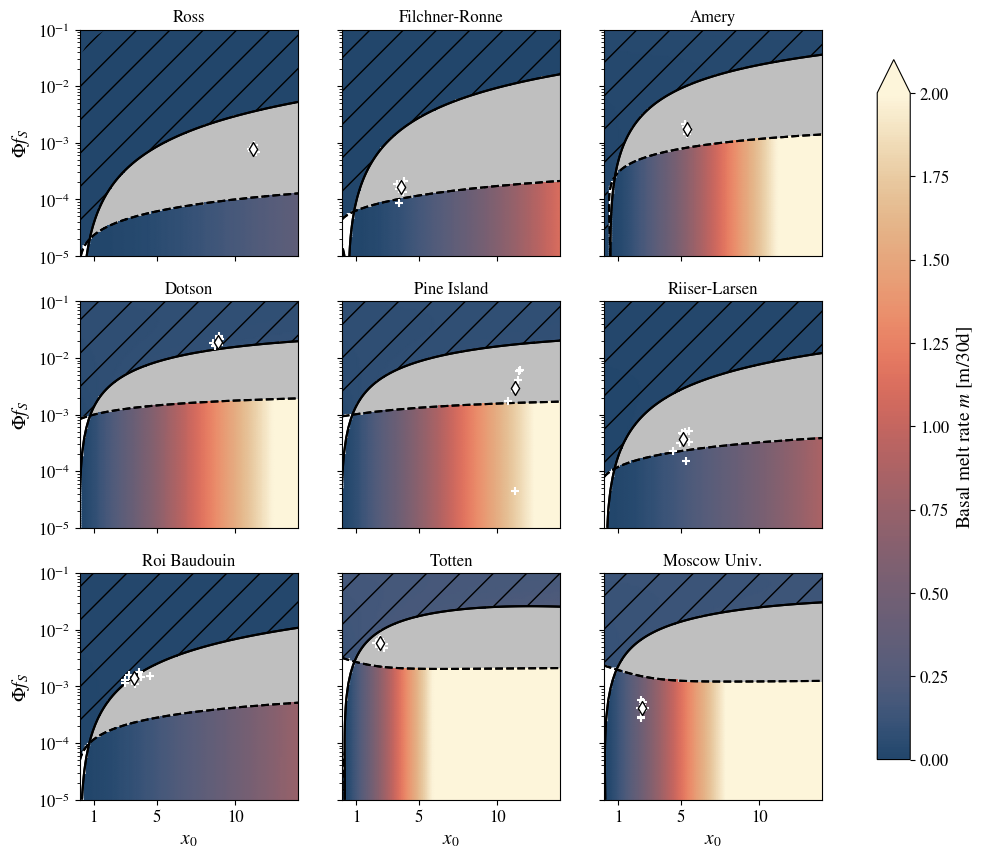

In [63]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(0) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True, sharey=True)

Npoint = 100 #Number of points in the figures (total is Npoint**2)



for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(-5,-1,Npoint)
    Ap_list = y_axis*rho_w/rho_i/Omega_ref*Ac*gammaT

    x_axis = np.linspace(0.1,14,Npoint)
    #WDW temperature
    Tb1 = fbm.liquidus(fbm.S_star,inputs.depth.sel(box=1, Nisf=index).values)
    Ts = fbm.liquidus(fbm.S_star,0)
    T0_list = (Ts-Tb1)*x_axis+Tb1
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    ax[i,j].pcolormesh(x_axis, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    melt_diff = ax[i,j].pcolormesh(x_axis, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(x_axis, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    ax[i,j].contour(x_axis, y_axis, sigma_d,colors='black',levels=0)
    ax[i,j].contour(x_axis, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(x_axis,y_axis,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(x_axis,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),hatches='/',levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(x_axis,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((0.1,14))
    ax[i,j].set_xticks([1,5,10])
    
    #ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6)) # Submitted Version
    ax[i,j].set_ylim((1e-5,1e-1)) # same y-axis,
    
    
    if j==0:
        ax[i,j].set_ylabel(r'$\Phi f_S$')
    if i==2:
        ax[i,j].set_xlabel(r'$x_0$')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    x0_series = (T0_series-Tb1)/(Ts-Tb1)
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values*2/3 #2/3 factors because only March to October rates here
    
    ax[i,j].scatter(x0_series,Ap_series*Omega_ref*rho_i/(rho_w*Ac*gammaT),marker='+', c='white', zorder=2) 
    ax[i,j].scatter(np.mean(x0_series),np.mean(Ap_series)*Omega_ref*rho_i/(rho_w*Ac*gammaT),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/30d]', extend='max')
#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

### $\Phi f_S \times \chi_\mathrm{conv}x_0$

Ross
Filchner-Ronne
Amery
Dotson
Pine Island
Riiser-Larsen
Roi Baudouin
Totten
Moscow Univ.


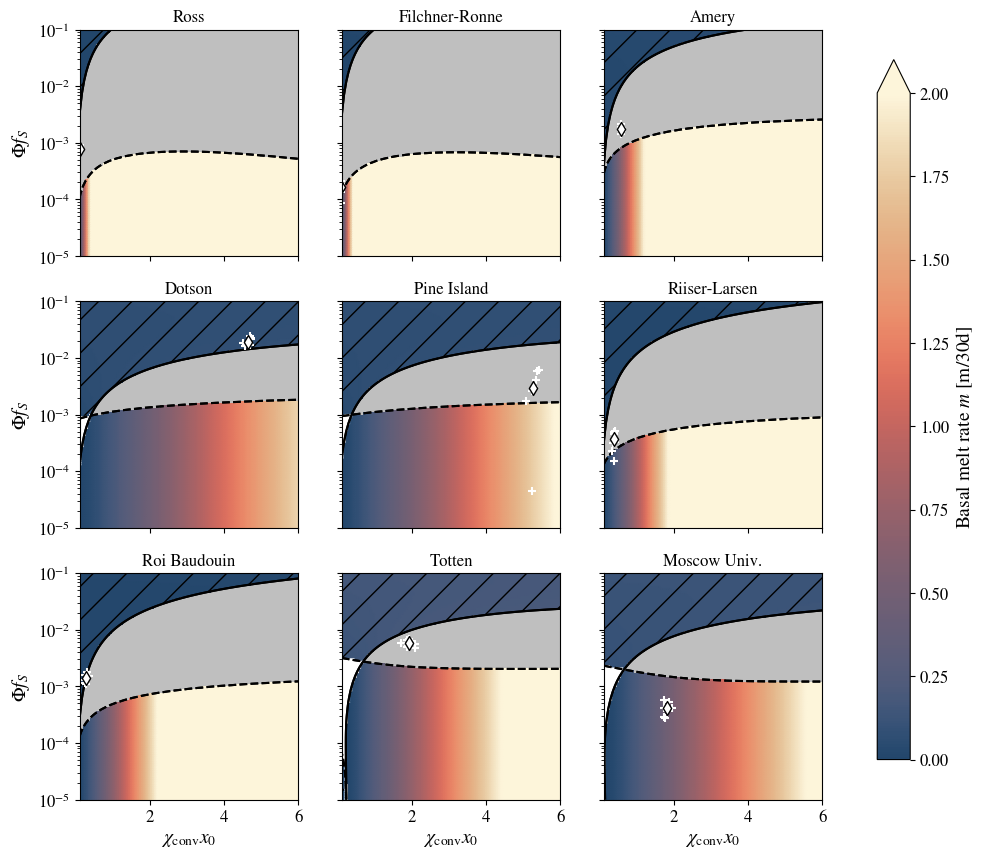

In [147]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(58) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True, sharey=True)

Npoint = 100 #Number of points in the figures (total is Npoint**2)



for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(-5,-1,Npoint)
    Ap_list = y_axis*rho_w/rho_i/Omega_ref*Ac*gammaT

    
    # Liquidus
    Tb1 = fbm.liquidus(fbm.S_star,inputs.depth.sel(box=1, Nisf=index).values)
    Ts = fbm.liquidus(fbm.S_star,0)

    Ctilde = C*rho_w/Ac/gammaT*(fbm.beta*fbm.c_star/fbm.L*fbm.S_star-fbm.alpha)*(Ts-Tb1)
    chi = (-1+np.sqrt(1+4*Ctilde))/2

    x_axis = np.linspace(0.1,6,Npoint)
    
    x0_list = x_axis/chi
    T0_list = (Ts-Tb1)*x0_list+Tb1

    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    ax[i,j].pcolormesh(x_axis, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    melt_diff = ax[i,j].pcolormesh(x_axis, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(x_axis, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    ax[i,j].contour(x_axis, y_axis, sigma_d,colors='black',levels=0)
    ax[i,j].contour(x_axis, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(x_axis,y_axis,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(x_axis,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),hatches='/',levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(x_axis,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((0.1,6))
    #ax[i,j].set_xticks([1,5,10])
    
    #ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6)) # Submitted Version
    ax[i,j].set_ylim((1e-5,1e-1)) # same y-axis,
    
    
    if j==0:
        ax[i,j].set_ylabel(r'$\Phi f_S$')
    if i==2:
        ax[i,j].set_xlabel(r'$\chi_\mathrm{conv}x_0$')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    x0_series = (T0_series-Tb1)/(Ts-Tb1)
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values*2/3 #2/3 factors because only March to October rates here
    
    ax[i,j].scatter(chi*x0_series,Ap_series*Omega_ref*rho_i/(rho_w*Ac*gammaT),marker='+', c='white', zorder=2) 
    ax[i,j].scatter(chi*np.mean(x0_series),np.mean(Ap_series)*Omega_ref*rho_i/(rho_w*Ac*gammaT),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/30d]', extend='max')
#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

### $\Phi f_S \times \chi_\mathrm{diff} x_0$

In [110]:
np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())

/tmp/ipykernel_1362/1501324698.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())


array([0.09544954, 0.13745227, 0.17056198, 0.1990371 , 0.2245332 ,
       0.24790213, 0.26965147, 0.29011287, 0.30951735, 0.3280335 ,
       0.34578894, 0.36288304, 0.37939502, 0.39538922, 0.41091882,
       0.42602832, 0.44075546, 0.45513256, 0.46918754, 0.48294477,
       0.49642562, 0.50964898, 0.52263166, 0.53538866, 0.54793349,
       0.56027829, 0.57243412, 0.584411  , 0.59621808, 0.60786376,
       0.61935574, 0.63070112, 0.64190646, 0.65297782, 0.66392085,
       0.67474079, 0.68544253, 0.69603063, 0.70650937, 0.71688276,
       0.72715455, 0.73732829, 0.7474073 , 0.75739474, 0.76729356,
       0.77710659, 0.78683648, 0.79648575, 0.8060568 , 0.8155519 ])

Ross


/tmp/ipykernel_1362/373112245.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  x0_list = np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())


Filchner-Ronne


/tmp/ipykernel_1362/373112245.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  x0_list = np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())


Amery


...

/tmp/ipykernel_1362/373112245.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  x0_list = np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())


Totten


/tmp/ipykernel_1362/373112245.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  x0_list = np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())


Moscow Univ.


/tmp/ipykernel_1362/373112245.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  x0_list = np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())


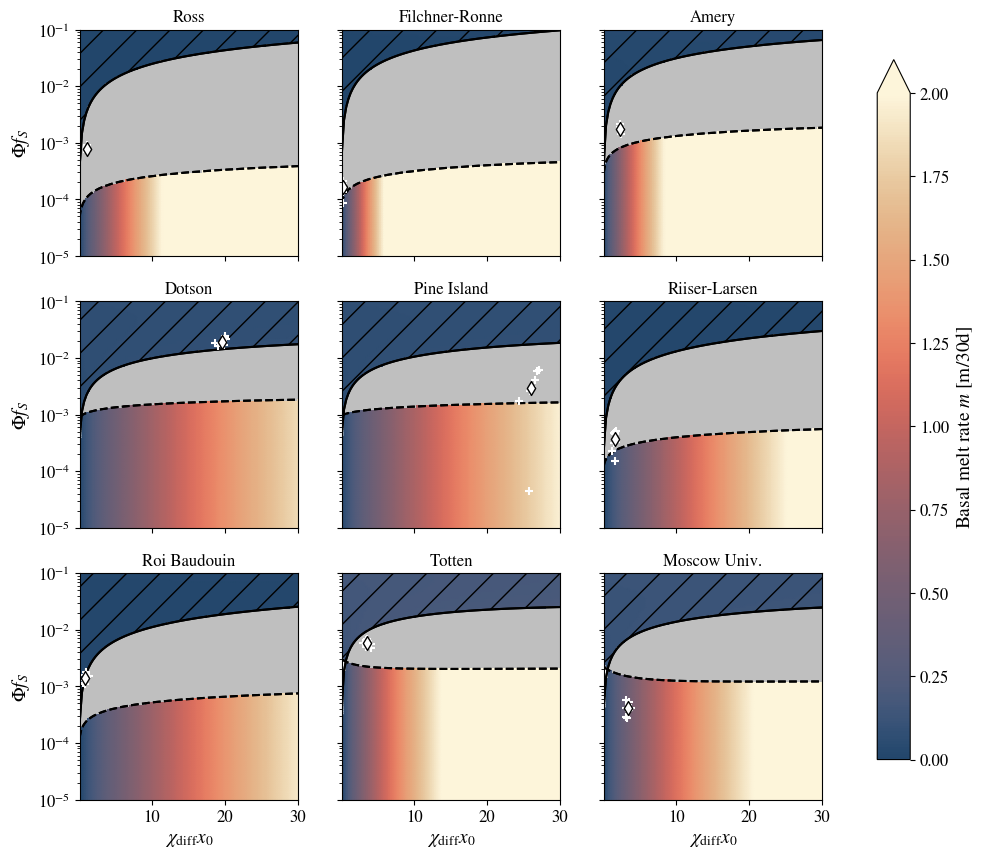

In [143]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(558) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True, sharey=True)

Npoint = 100 #Number of points in the figures (total is Npoint**2)



for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(-5,-1,Npoint)
    Ap_list = y_axis*rho_w/rho_i/Omega_ref*Ac*gammaT

    
    # Liquidus
    Tb1 = fbm.liquidus(fbm.S_star,inputs.depth.sel(box=1, Nisf=index).values)
    Ts = fbm.liquidus(fbm.S_star,0)

    Ctilde = C*rho_w/Ac/gammaT*(fbm.beta*fbm.c_star/fbm.L*fbm.S_star-fbm.alpha)*(Ts-Tb1)

    x_axis = np.linspace(0.1,30,Npoint)
    
    x0_list = np.array([np.max(np.roots([Ctilde, 0, -val, -val**2])) for val in x_axis],dtype=np.float64())
    
    T0_list = (Ts-Tb1)*x0_list+Tb1

    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    ax[i,j].pcolormesh(x_axis, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    melt_diff = ax[i,j].pcolormesh(x_axis, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(x_axis, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    ax[i,j].contour(x_axis, y_axis, sigma_d,colors='black',levels=0)
    ax[i,j].contour(x_axis, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(x_axis,y_axis,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(x_axis,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),hatches='/',levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(x_axis,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((0.1,30))
    #ax[i,j].set_xticks([1,5,10])
    
    #ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6)) # Submitted Version
    ax[i,j].set_ylim((1e-5,1e-1)) # same y-axis,
    
    
    if j==0:
        ax[i,j].set_ylabel(r'$\Phi f_S$')
    if i==2:
        ax[i,j].set_xlabel(r'$\chi_\mathrm{diff}x_0$')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    x0_series = (T0_series-Tb1)/(Ts-Tb1)
    chi_series = (-1+np.sqrt(1+4*Ctilde*x0_series))/2
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values*2/3 #2/3 factors because only March to October rates here
    
    ax[i,j].scatter(chi_series*x0_series,Ap_series*Omega_ref*rho_i/(rho_w*Ac*gammaT),marker='+', c='white', zorder=2) 
    ax[i,j].scatter(np.mean(chi_series*x0_series),np.mean(Ap_series)*Omega_ref*rho_i/(rho_w*Ac*gammaT),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/30d]', extend='max')
#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

### $A_p\times\Omega$, integrated melt rates, 3 columns

Pine Island
Dotson
Totten
Moscow Univ.


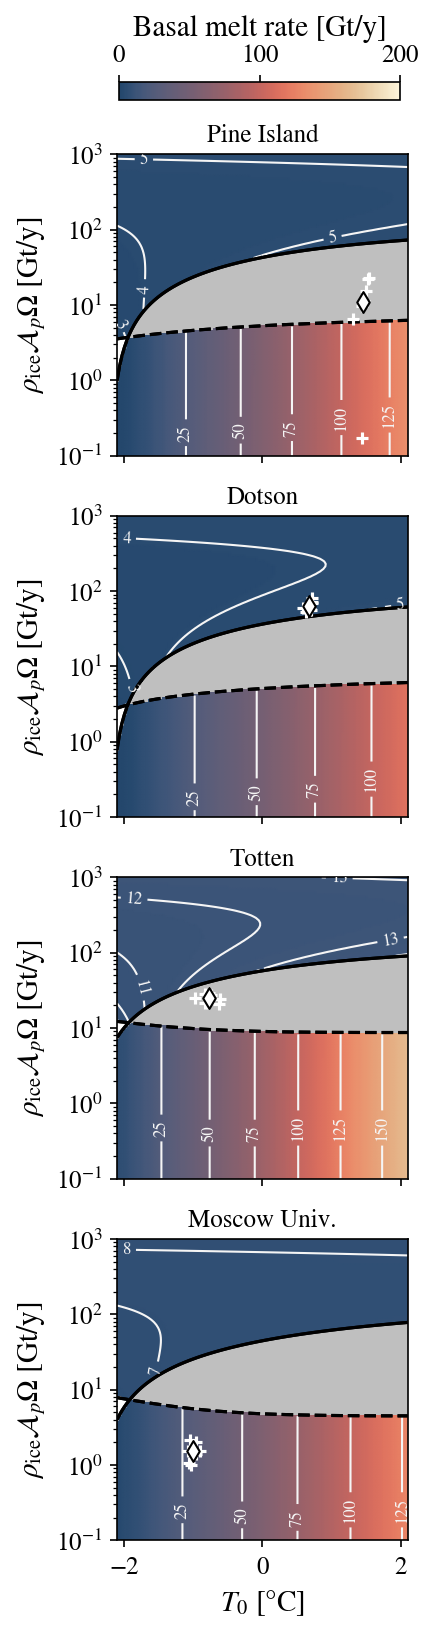

In [58]:
### Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(28) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(4,1,figsize=(2.5,12),sharex=True, sharey=True, dpi=150)

Npoint = 120 #Number of points in the figures (total is Npoint**2)

#WDW temperature
T0_list = np.linspace(-2.1,2.1,Npoint) # For the x-axis


index_small = [66,52,48,33]
name_small = ['Pine Island', 'Dotson', 'Totten', 'Moscow Univ.']


for k, index, name in zip(np.arange(len(index_small)),index_small,name_small):

    kmax = 3
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here

    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(-1,3,Npoint)
    Ap_list = y_axis/Omega_ref/rho_i *1e12/3600/24/365.25
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    melt_c = melt_c*12 *rho_i*Ac /1e12 # Gt/y
    ax[k].pcolormesh(T0_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=200,shading='gouraud') # Ap in km²

    contour_c = np.ma.masked_where(stability_map !=-1,melt_c)
    cont_c = ax[k].contour(T0_list, y_axis, contour_c, np.arange(0,20,1), colors='whitesmoke', linewidths=1) 

    melt_d = melt_d*12 *rho_i*Ac /1e12 # Gt/y
    melt_diff = ax[k].pcolormesh(T0_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=200,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[k].pcolormesh(T0_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    contour_d = np.ma.masked_where(stability_map !=1,melt_d)
    cont_d = ax[k].contour(T0_list, y_axis, contour_d, np.arange(0,200,25), colors='whitesmoke', linewidths=1.)
    

    ax[k].contour(T0_list, y_axis, sigma_d,colors='black',levels=0)
    ax[k].contour(T0_list, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[k].contour(T0_list,y_axis,sigma_d,colors='black',levels=0)
        ax[k].contourf(T0_list,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),
                         levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[k].contour(T0_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[k].set_title(name)
    ax[k].set_yscale('log')
    ax[k].set_xlim((-2.1,2.1))
    
    ax[k].set_ylim((1e-1,1e3)) # same y-axis
    ax[k].set_ylabel(r'$\rho_\mathrm{ice} \mathcal{A}_p \Omega$'+' '+r'$\mathrm{[Gt/y]}$')
    
    if k==kmax:
        ax[k].set_xlabel(r'$T_0$'+' [°C]')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    SeaIce_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values *rho_i*Omega_ref *24*3600*365.25/1e12    *2/3 #2/3 factors because only March to October rates here
    
    ax[k].scatter(T0_series,SeaIce_series,marker='+', c='white', zorder=2) 
    ax[k].scatter(np.mean(T0_series),np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    ax[k].clabel(cont_c, fontsize=8)
    ax[k].clabel(cont_d, fontsize=8)

    
cbar_ax = fig.add_axes([0.13, 0.91, 0.75, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(melt_diff, cax=cbar_ax, orientation='horizontal',
             label='Basal melt rate [Gt/y]')
# Move ticks and label to the top
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

Ross
Filchner-Ronne
Amery


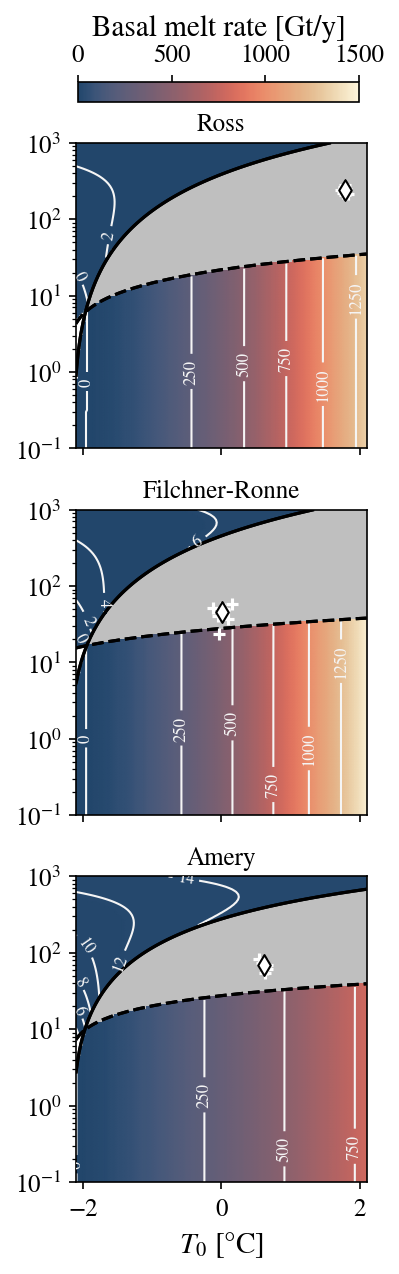

In [60]:
### Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(28) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(3,1,figsize=(2.5,9),sharex=True, sharey=True, dpi=150)

Npoint = 120 #Number of points in the figures (total is Npoint**2)

#WDW temperature
T0_list = np.linspace(-2.1,2.1,Npoint) # For the x-axis


index_small = [10,11,31]
name_small = ['Ross', 'Filchner-Ronne', 'Amery',]


for k, index, name in zip(np.arange(len(index_small)),index_small,name_small):

    kmax = 2
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here

    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(-1,3,Npoint)
    Ap_list = y_axis/Omega_ref/rho_i *1e12/3600/24/365.25
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    melt_c = melt_c*12 *rho_i*Ac /1e12 # Gt/y
    ax[k].pcolormesh(T0_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=1500,shading='gouraud') # Ap in km²

    contour_c = np.ma.masked_where(stability_map !=-1,melt_c)
    cont_c = ax[k].contour(T0_list, y_axis, contour_c, np.arange(0,20,2), colors='whitesmoke', linewidths=1) 
    

    melt_d = melt_d*12 *rho_i*Ac /1e12 # Gt/y
    melt_diff = ax[k].pcolormesh(T0_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=1500,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[k].pcolormesh(T0_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    contour_d = np.ma.masked_where(stability_map !=1,melt_d)
    cont_d = ax[k].contour(T0_list, y_axis, contour_d, np.arange(0,1500,250), colors='whitesmoke', linewidths=1.)

    ax[k].contour(T0_list, y_axis, sigma_d,colors='black',levels=0)
    ax[k].contour(T0_list, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[k].contour(T0_list,y_axis,sigma_d,colors='black',levels=0)
        ax[k].contourf(T0_list,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),
                         levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[k].contour(T0_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[k].set_title(name)
    ax[k].set_yscale('log')
    ax[k].set_xlim((-2.1,2.1))
    
    ax[k].set_ylim((1e-1,1e3)) # same y-axis
    #ax[k].set_ylabel(r'$\rho_\mathrm{ice} \mathcal{A}_p \Omega$'+' '+r'$\mathrm{[Gt/y]}$')
    
    if k==kmax:
        ax[k].set_xlabel(r'$T_0$'+' [°C]')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    SeaIce_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values *rho_i*Omega_ref *24*3600*365.25/1e12    *2/3 #2/3 factors because only March to October rates here
    
    ax[k].scatter(T0_series,SeaIce_series,marker='+', c='white', zorder=2) 
    ax[k].scatter(np.mean(T0_series),np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    ax[k].clabel(cont_c, fontsize=8)
    ax[k].clabel(cont_d, fontsize=8)

    
cbar_ax = fig.add_axes([0.13, 0.91, 0.75, 0.01*3/2])  # [left, bottom, width, height]
cbar = fig.colorbar(melt_diff, cax=cbar_ax, orientation='horizontal',
             label='Basal melt rate [Gt/y]')
# Move ticks and label to the top
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()

Riiser-Larsen
Roi Baudouin
no conv, diff 0 1


/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/Figure3_try/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


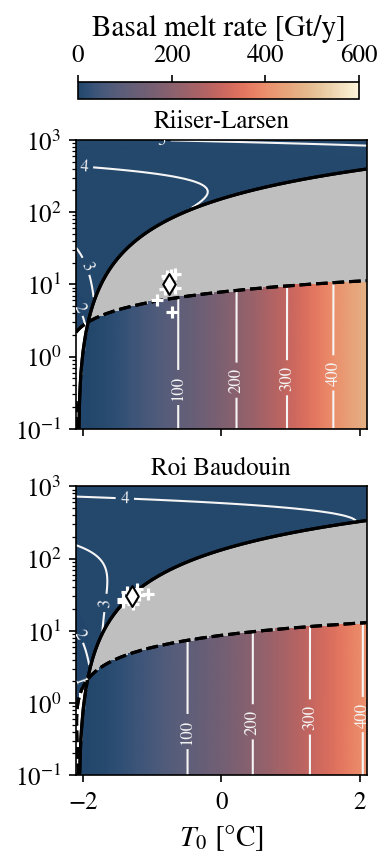

In [59]:
### Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(28) # this random see works well

AABW = False # If you want to include AABW parameterisation

fig, ax = plt.subplots(2,1,figsize=(2.5,5.5),sharex=True, sharey=True, dpi=150)

Npoint = 120 #Number of points in the figures (total is Npoint**2)

#WDW temperature
T0_list = np.linspace(-2.1,2.1,Npoint) # For the x-axis


index_small = [43,45]
name_small = ['Riiser-Larsen', 'Roi Baudouin',]


for k, index, name in zip(np.arange(len(index_small)),index_small,name_small):

    kmax = 1
    print(name)

    #Polynya extents
    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor because only march to october rates here

    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor because only march to october rates here
    y_axis = np.logspace(-1,3,Npoint)
    Ap_list = y_axis/Omega_ref/rho_i *1e12/3600/24/365.25
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    # initial guess for the steady stae of the system
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(fbm.BoxModel, guess_diff, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            # update initial guess
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = fbm.compute_Sigma(X_d)
                stability_d[m,n] = fbm.compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt,q = fbm.PICO(X_d[1],X_d[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_d[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(fbm.BoxModel, guess_conv, args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            # update initial guess
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = fbm.compute_Sigma(X_c)
                stability_c[m,n] = fbm.compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt,q = fbm.PICO(X_c[1],X_c[3], nbox, C, gammaT, Ac, frac, depth)
                    melt_c[m,n] = fbm.compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    melt_c = melt_c*12 *rho_i*Ac /1e12 # Gt/y
    ax[k].pcolormesh(T0_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=600,shading='gouraud') # Ap in km²

    contour_c = np.ma.masked_where(stability_map !=-1,melt_c)
    cont_c = ax[k].contour(T0_list, y_axis, contour_c, np.arange(0,10,1), colors='whitesmoke', linewidths=1) 
    

    melt_d = melt_d*12 *rho_i*Ac /1e12 # Gt/y
    melt_diff = ax[k].pcolormesh(T0_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=600,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[k].pcolormesh(T0_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    contour_d = np.ma.masked_where(stability_map !=1,melt_d)
    cont_d = ax[k].contour(T0_list, y_axis, contour_d, np.arange(0,500,100), colors='whitesmoke', linewidths=1.)

    ax[k].contour(T0_list, y_axis, sigma_d,colors='black',levels=0)
    ax[k].contour(T0_list, y_axis, sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[k].contour(T0_list,y_axis,sigma_d,colors='black',levels=0)
        ax[k].contourf(T0_list,y_axis,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),
                         levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[k].contour(T0_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[k].set_title(name)
    ax[k].set_yscale('log')
    ax[k].set_xlim((-2.1,2.1))
    
    ax[k].set_ylim((1e-1,1e3)) # same y-axis
    #ax[k].set_ylabel(r'$\rho_\mathrm{ice} \mathcal{A}_p \Omega$'+' '+r'$\mathrm{[Gt/y]}$')
    
    if k==kmax:
        ax[k].set_xlabel(r'$T_0$'+' [°C]')

    # series of yearly averages 
    T0_series = inputs.T0.sel(Nisf=index).values
    SeaIce_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values *rho_i*Omega_ref *24*3600*365.25/1e12    *2/3 #2/3 factors because only March to October rates here
    
    ax[k].scatter(T0_series,SeaIce_series,marker='+', c='white', zorder=2) 
    ax[k].scatter(np.mean(T0_series),np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean

    ax[k].clabel(cont_c, fontsize=8)
    ax[k].clabel(cont_d, fontsize=8)

    
cbar_ax = fig.add_axes([0.13, 0.93, 0.75, 0.01*2])  # [left, bottom, width, height]
cbar = fig.colorbar(melt_diff, cax=cbar_ax, orientation='horizontal',
             label='Basal melt rate [Gt/y]')
# Move ticks and label to the top
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

#plt.savefig('Figures/Figure3.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()